In [1]:
#import the datasets
import pandas as pd
import matplotlib.pyplot as plt # https://matplotlib.org/
import numpy as np # http://www.numpy.org/


#load data
filename = "Ac20h000.csv"
df = pd.read_csv(filename)

#keep columns we care about
df = df[['event', 'anode', 'amplitude', 'risetime']].copy()

#ensure numeric
df['amplitude'] = pd.to_numeric(df['amplitude'], errors='coerce')
df['risetime'] = pd.to_numeric(df['risetime'], errors='coerce')

amp_df = df.pivot_table(index='event', columns='anode', values='amplitude', aggfunc='first')
amp_df = amp_df.rename(columns={col: f"{col}_amplitude" for col in amp_df.columns})

rise_df = df.pivot_table(index='event', columns='anode', values='risetime', aggfunc='first')
rise_df = rise_df.rename(columns={col: f"{col}_risetime" for col in rise_df.columns})

#combine into one dataframe
event_df = pd.concat([amp_df, rise_df], axis=1).reset_index()

#identify anode with highest amplitude for each anode
sphere_amplitude_cols = [col for col in event_df.columns if col.endswith('_amplitude') and not col.startswith('Laser')]
event_df['max_anode'] = event_df[sphere_amplitude_cols].idxmax(axis=1)
#identify which risetime corresponds to this anode and event
event_df['max_anode'] = event_df['max_anode'].str.replace('_amplitude', '', regex=False)
event_df['risetime'] = [event_df.loc[i, f"{anode}_risetime"] if pd.notna(anode) else np.nan for i, anode in event_df['max_anode'].items()]

#sum together all of the sphere anode amplitudes and create a new column of 'summed_amplitude'
event_df['summed_amplitude'] = event_df[sphere_amplitude_cols].sum(axis=1)

pos_amp = event_df[sphere_amplitude_cols] > 0
event_df['pos_summed_amplitude'] = event_df[pos_amp].sum(axis=1)

#some of the veto rows will be empty - only keep if amplitude above some nominal noise, say 200ADU
events_which_trigger_veto = event_df[event_df['Laser_amplitude'].abs() > 200] #these are the muons
#remove events which trigger the veto from the sphere data frame
events_after_veto_df = event_df[~event_df['event'].isin(events_which_trigger_veto['event'])] #this has (some) muons removed

print('all events')
print(len(event_df))
print('muon events')
print(len(events_which_trigger_veto))
print('events left after veto')
print(len(events_after_veto_df))

all events
65287
muon events
9779
events left after veto
55508


percentage of muons in sphere vetoed: 15.130279371648953


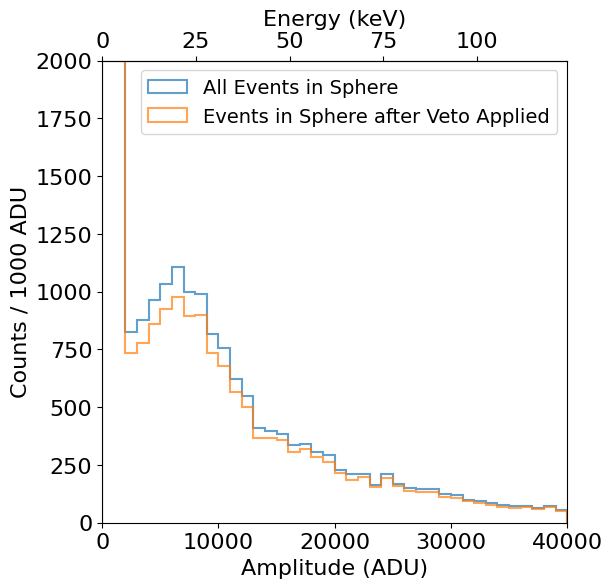

In [19]:
#amplitude distribution
conversion_factor = 3.1e-3
lower_amp = 0
upper_amp = 35952
bins = np.arange(0, 40001, 1000)  # 1000 ADU bin width

before = len(event_df[
    (event_df['summed_amplitude'].abs() >= lower_amp) &
    (event_df['summed_amplitude'].abs() <= upper_amp)
])

after = len(events_after_veto_df[
    (events_after_veto_df['summed_amplitude'].abs() >= lower_amp) &
    (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)
])

percentage_vetoed = ((before - after) / before) * 100

plt.figure(figsize=(6,6))
plt.hist(event_df['summed_amplitude'], bins=bins, alpha = 0.7,linewidth=1.5,label = 'All Events in Sphere',histtype='step')
plt.hist(events_after_veto_df['summed_amplitude'], bins=bins, alpha = 0.7,linewidth=1.5, label = 'Events in Sphere after Veto Applied',histtype='step')
plt.xlim(0, 40000)
plt.xlabel('Amplitude (ADU)', fontsize=16)
plt.ylim(0, 2000)
#plt.axvline(2000)
#plt.axvline(4869)
plt.ylabel('Counts / 1000 ADU', fontsize=16) 
plt.tick_params('both', labelsize=16)
#plt.title(filename)
plt.legend(fontsize=14)
ax1 = plt.gca()
def adu_to_keV(x):
    return x * conversion_factor
def keV_to_adu(x):
    return x / conversion_factor
ax2 = ax1.secondary_xaxis('top', functions=(adu_to_keV, keV_to_adu))
ax2.set_xlabel('Energy (keV)', fontsize=16)
ax2.tick_params('x', labelsize=16)

print('percentage of muons in sphere vetoed:', percentage_vetoed)


percentage of muons in sphere vetoed: 16.163144748117485


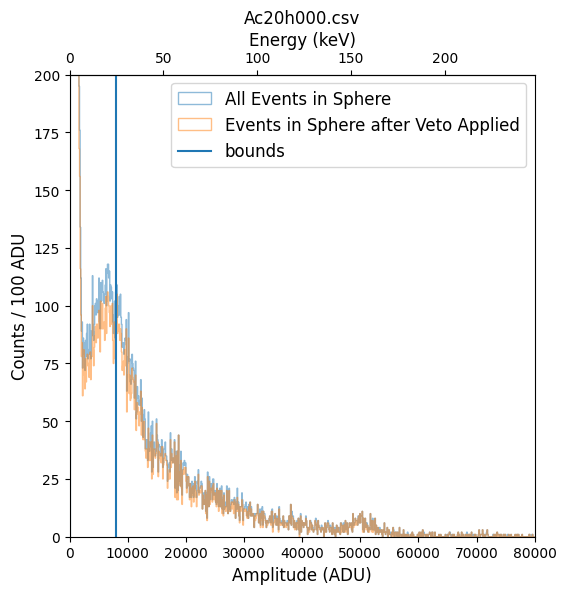

In [3]:
#amplitude distribution
lower_amp = 0
upper_amp = 8029
bins = np.arange(0, 80001, 100)  # 100 ADU bin width

before = len(event_df[
    (event_df['summed_amplitude'].abs() >= lower_amp) &
    (event_df['summed_amplitude'].abs() <= upper_amp)
])

after = len(events_after_veto_df[
    (events_after_veto_df['summed_amplitude'].abs() >= lower_amp) &
    (events_after_veto_df['summed_amplitude'].abs() <= upper_amp)
])

percentage_vetoed = (1 - after / before) * 100

plt.figure(figsize=(6,6))
plt.hist(event_df['summed_amplitude'], bins=bins, alpha = 0.5,label = 'All Events in Sphere',histtype='step')
plt.hist(events_after_veto_df['summed_amplitude'], bins=bins, alpha = 0.5, label = 'Events in Sphere after Veto Applied',histtype='step')
plt.xlim(0, 80000)
plt.xlabel('Amplitude (ADU)', fontsize=12)
plt.ylim(0, 200)
plt.axvline(lower_amp, label = 'bounds')
plt.axvline(upper_amp)
plt.ylabel('Counts / 100 ADU', fontsize=12) 
plt.title(filename)
plt.legend(fontsize=12)
ax1 = plt.gca()
def adu_to_keV(x):
    return x * conversion_factor
def keV_to_adu(x):
    return x / conversion_factor
ax2 = ax1.secondary_xaxis('top', functions=(adu_to_keV, keV_to_adu))
ax2.set_xlabel('Energy (keV)', fontsize=12)

print('percentage of muons in sphere vetoed:', percentage_vetoed)

In [4]:
#pos_amp = event_df[sphere_amplitude_cols] > 0
#event_df['pos_summed_amplitude'] = event_df[pos_amp].sum(axis=1)

#print(pos_amp)

print('F0', np.sum(pos_amp['F0_amplitude']==True))
print('F1', np.sum(pos_amp['F1_amplitude']==True))
print('F2', np.sum(pos_amp['F2_amplitude']==True))
print('F3', np.sum(pos_amp['F3_amplitude']==True))
print('F4', np.sum(pos_amp['F4_amplitude']==True))
print('F5', np.sum(pos_amp['F5_amplitude']==True))
print('N1', np.sum(pos_amp['N1_amplitude']==True))
print('N2', np.sum(pos_amp['N2_amplitude']==True))
print('N3', np.sum(pos_amp['N3_amplitude']==True))
print('N4', np.sum(pos_amp['N4_amplitude']==True))
print('N5', np.sum(pos_amp['N5_amplitude']==True))


F0 23046
F1 24880
F2 24902
F3 29182
F4 24803
F5 23123
N1 38775
N2 39914
N3 29110
N4 41003
N5 40167
